<p align="center">
  <strong><font size="6">Ordinary Least Squares from Scratch</font></strong><br>
    <strong><font size="4">For Simple Linear Regression</font></strong>
</p>


## Boston Housing Data Dictionary

A dataset containing housing values in 506 suburbs of Boston.

- **crim**: Per capita crime rate by town.
- **zn**: Proportion of residential land zoned for lots over 25,000 sq.ft.
- **indus**: Proportion of non-retail business acres per town.
- **chas**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- **nox**: Nitrogen oxides concentration (parts per 10 million).
- **rm**: Average number of rooms per dwelling.
- **age**: Proportion of owner-occupied units built prior to 1940.
- **dis**: Weighted mean of distances to five Boston employment centres.
- **rad**: Index of accessibility to radial highways.
- **tax**: Full-value property-tax rate per \$10,000.
- **ptratio**: Pupil-teacher ratio by town.
- **lstat**: Percentage of lower status population.
- **medv**: Median value of owner-occupied homes (in \$1000s).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as variance_inflation_factor
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

In [2]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [3]:
Boston.shape

(506, 13)

In [4]:
Boston.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


In [5]:
X = pd.DataFrame({'intercept':np.ones(Boston.shape[0]),
                  'lstat': Boston['lstat']})
y = Boston['medv']
model = sm.OLS(y,X)
results = model.fit()
y_pred_sm = results.predict(X)

In [6]:
print(results.params)

intercept    34.553841
lstat        -0.950049
dtype: float64


In [7]:
#OLS from scratch 
X_np = X.values
y_np = y.values

print(X_np[:4],y_np[:4])

a = np.linalg.inv(X_np.T @ X_np) # (2xn @ nx2) = 2x2 inverse = 2x2
b = X_np.T @ y_np  # (2xn) @ (nx1) = 2x1
beta_hat = a @ b   # (2x2) @ (2x1) = 2x1

print(f"Intercept: {beta_hat[0]:.4f}")
print(f"lstat Coefficient: {beta_hat[1]:.4f}")
y_pred_scratch = X_np @ beta_hat

[[1.   4.98]
 [1.   9.14]
 [1.   4.03]
 [1.   2.94]] [24.  21.6 34.7 33.4]
Intercept: 34.5538
lstat Coefficient: -0.9500


In [8]:
np.allclose(y_pred_sm, y_pred_scratch)


True

In [9]:
residuals_sm = y - y_pred_sm
residuals_scratch = y - y_pred_scratch
np.allclose(residuals_sm, residuals_scratch)

True

In [10]:
rss_sm = np.sum(residuals_sm ** 2)
rss_scratch = np.sum(residuals_scratch ** 2)
np.allclose(rss_sm,rss_scratch)

True

In [11]:
print(f"RSS (statsmodels): {rss_sm:.4f}")
print(f"RSS (scratch):     {rss_scratch:.4f}")


RSS (statsmodels): 19472.3814
RSS (scratch):     19472.3814


In [12]:
#Residual Standard Error - how much on an avg the response deviates from the true regression line. its the estimate for the standard deviation of Error.
n = X.shape[0]
p = 1
rse_sm = np.sqrt(rss_sm/n-p-1)
rse_scratch = np.sqrt(rss_scratch/n-p-1)

print(f"residual standard error from SM: {rse_sm:.4f}")
print(f"residual standard error from scratch: {rse_scratch:.4f}")


residual standard error from SM: 6.0401
residual standard error from scratch: 6.0401


In [13]:
TSS = np.sum((y_np - np.mean(y_np))**2)

r2_sm = results.rsquared
r2_scratch = 1-(rss_scratch/TSS)

print(f"R² (statsmodels): {r2_sm:.4f}")
print(f"R² (scratch):     {r2_scratch:.4f}")

R² (statsmodels): 0.5441
R² (scratch):     0.5441


In [14]:
print(f"Intercept (scratch): {beta_hat[0]:.4f}")
print(f"lstat Coefficient (scratch): {beta_hat[1]:.4f}")
print(f"Intercept and lstat coeff from SM: {results.params}")

print("--------------"*10)

print("Are both the predictions almost same?", np.allclose(results.fittedvalues, y_pred_scratch))

print("--------------"*10)

print("Are both the error residuals almost same?", np.allclose(results.resid, residuals_scratch))

print("--------------"*10)

print(f"RSS (statsmodels): {results.ssr:.4f}")
print(f"RSS (scratch):     {rss_scratch:.4f}")

print("--------------"*10)

print(f"residual standard error from SM: {rse_sm:.4f}")
print(f"residual standard error from scratch: {rse_scratch:.4f}")

print("--------------"*10)

print(f"R² (statsmodels): {r2_sm:.4f}")
print(f"R² (scratch):     {r2_scratch:.4f}")


Intercept (scratch): 34.5538
lstat Coefficient (scratch): -0.9500
Intercept and lstat coeff from SM: intercept    34.553841
lstat        -0.950049
dtype: float64
--------------------------------------------------------------------------------------------------------------------------------------------
Are both the predictions almost same? True
--------------------------------------------------------------------------------------------------------------------------------------------
Are both the error residuals almost same? True
--------------------------------------------------------------------------------------------------------------------------------------------
RSS (statsmodels): 19472.3814
RSS (scratch):     19472.3814
--------------------------------------------------------------------------------------------------------------------------------------------
residual standard error from SM: 6.0401
residual standard error from scratch: 6.0401
---------------------------------------

In [15]:
design = MS(['lstat'])
X = design.fit_transform(Boston) 
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [16]:
new_df = pd.DataFrame({'lstat':[5,10,15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


## The get_prediction() method can be used to obtain predictions, and produce confidence intervals and prediction intervals for the prediction of medv for given values of lstat.

In [17]:
new_predictions = results.get_prediction(newX)


In [18]:
dir(new_predictions)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'conf_int',
 'df',
 'dist',
 'dist_args',
 'predicted',
 'predicted_mean',
 'row_labels',
 'se',
 'se_mean',
 'se_obs',
 'summary_frame',
 'var_pred',
 'var_pred_mean',
 'var_resid']

In [19]:
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [20]:
new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [21]:
new_predictions.conf_int(obs=True, alpha = 0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [22]:
def abline(ax,b,m, *args, **kwargs):
    "Add a line with slope m and intecept b to ax"
    xlim = ax.get_xlim()
    ylim = [m*xlim[0]+b,m*xlim[1]+b]
    ax.plot(xlim,ylim,*args, **kwargs)


In [23]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

/var/folders/r4/v6h1hbkn63sf76_00l3p7v8m0000gn/T/ipykernel_948/2326796113.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax,results.params[0],results.params[1],'r--',linewidth=3)


[]

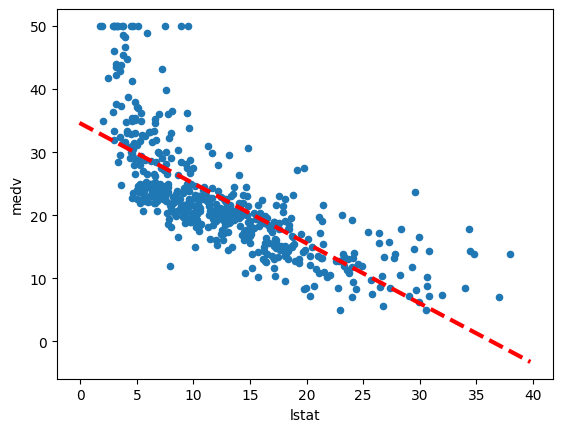

In [24]:
ax = Boston.plot.scatter('lstat','medv')
abline(ax,results.params[0],results.params[1],'r--',linewidth=3)
ax.plot()

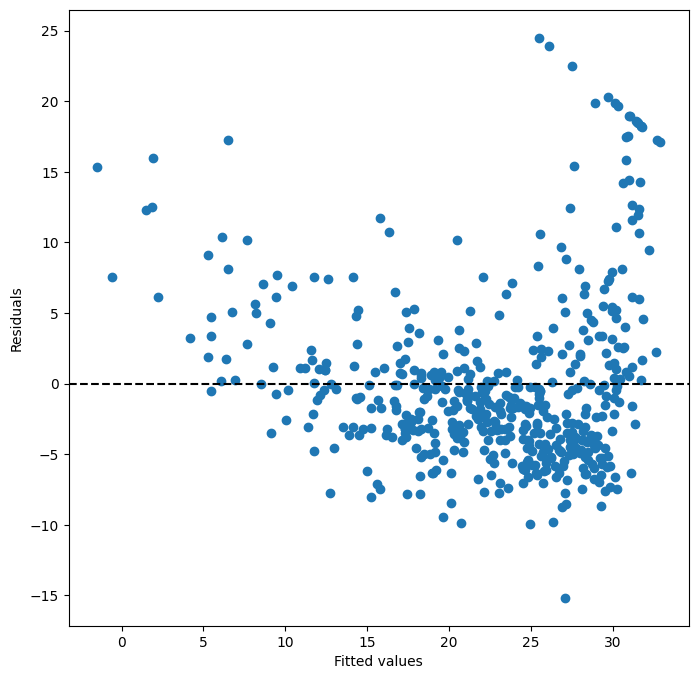

In [25]:
ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues,results.resid)
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.axhline(0,c='k',ls='--')

### We add a horizontal line at 0 for reference using the ax.axhline() method, indicating it should be black (c='k') and have a dashed linestyle (ls='--'). On the basis of the residual plot, there is some evidence of non-linearity. Leverage statistics can be computed for any number of predictors using the hat_matrix_diag attribute of the value returned by the get_influence() method.

np.int64(374)

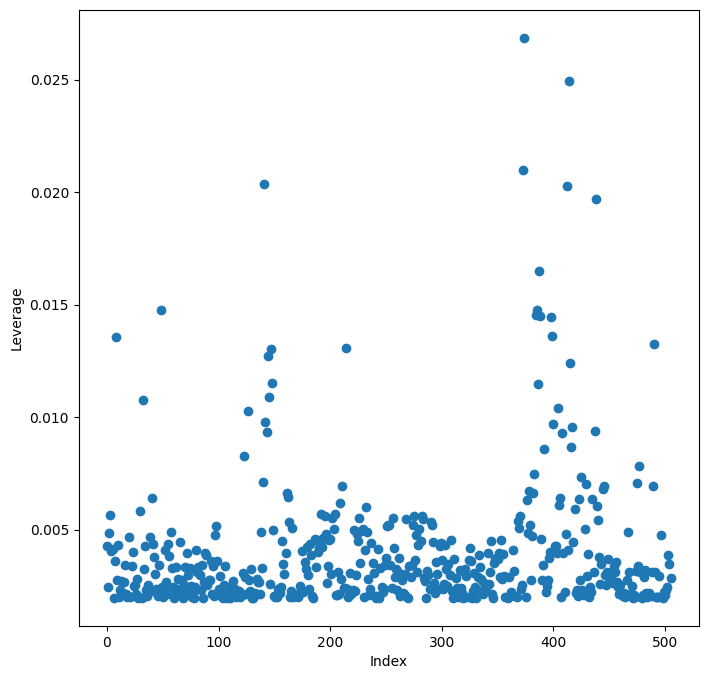

In [26]:
infl = results.get_influence()
ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag) 
ax.set_xlabel('Index')
ax.set_ylabel('Leverage') 
np.argmax(infl.hat_matrix_diag)

<p align="center">
  <strong><font size="6">Ordinary Least Squares from Scratch</font></strong><br>
    <strong><font size="4">For Multiple Linear Regression</font></strong>
</p>


In [27]:
predictors = Boston.columns.drop(['medv'])
predictors

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [28]:
X = MS(predictors).fit_transform(Boston)
mlr_model = sm.OLS(y,X)
results_mlr = mlr_model.fit()


In [29]:
summarize(results_mlr)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [30]:
predictors_minus_age = Boston.columns.drop(['medv','age'])
X_minus_age = MS(predictors_minus_age).fit_transform(Boston)
mlr_model_1 = sm.OLS(y,X_minus_age)
results_mlr_1 = mlr_model_1.fit()


In [31]:
summarize(results_mlr_1)

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


### Variance Inflation Factor (VIF)

In [32]:
vals = [variance_inflation_factor(X,i) for i in range(1,X.shape[1])]
vif = pd.DataFrame({'vif': vals},
                   index = X.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


### Interaction Terms

In [33]:
X_interaction = MS(['lstat','age',('lstat','age')]).fit_transform(Boston)
model_mlr_interaction = sm.OLS(y,X_interaction)
results_mlr_interaction = model_mlr_interaction.fit()

In [34]:
summarize(results_mlr_interaction)

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


### Non-Linear Transformations of the Predictors

In [35]:
X_poly = MS([poly('lstat',degree=2),'age']).fit_transform(Boston)
model_mlr_poly = sm.OLS(y,X_poly)
results_mlr_poly = model_mlr_poly.fit()
summarize(results_mlr_poly)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [36]:
X_poly[:10]

,intercept,"poly(lstat, degree=2)[0]","poly(lstat, degree=2)[1]",age
0,1.0,-0.047815,0.038955,65.2
1,1.0,-0.021892,-0.010782,78.9
2,1.0,-0.053734,0.053604,61.1
3,1.0,-0.060527,0.071920,45.8
4,1.0,-0.045634,0.033866,54.2
5,1.0,-0.046381,0.035592,58.7
6,1.0,-0.001390,-0.033498,66.6
7,1.0,0.040486,-0.034289,96.1
8,1.0,0.107661,0.092349,100.0
9,1.0,0.027711,-0.040539,85.9


In [37]:
X_basic = MS(['lstat','age']).fit_transform(Boston)
model_mlr_basic = sm.OLS(y,X_basic)
results_mlr_basic = model_mlr_basic.fit()
summarize(results_mlr_basic)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [38]:
anova_lm(results_mlr_basic,results_mlr_poly)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


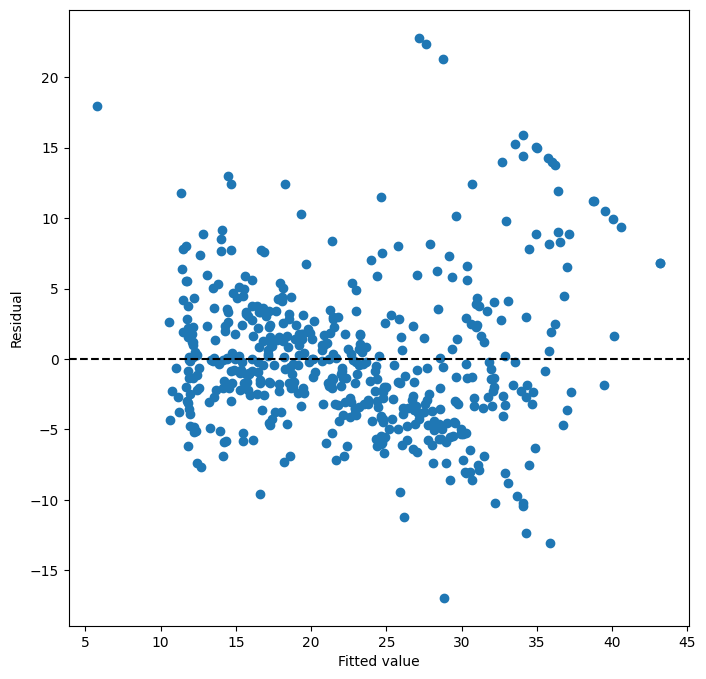

In [39]:
ax = plt.subplots(figsize=(8,8))[1] 
ax.scatter(results_mlr_poly.fittedvalues , results_mlr_poly.resid) 
ax.set_xlabel('Fitted value') 
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

<p align="center">
  <strong><font size="6">Qualitative predictors</font></strong><br>
</p>



In [40]:
Carseats = load_data('Carseats') 
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

### ShelveLoc, an indicator of the quality of the shelving location — that is, the space within a store in which the car seat is displayed. The predictor ShelveLoc takes on three possible values, Bad, Medium, and Good.

In [41]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']

In [42]:
allvars

['CompPrice',
 'Income',
 'Advertising',
 'Population',
 'Price',
 'ShelveLoc',
 'Age',
 'Education',
 'Urban',
 'US']

In [43]:
final = allvars + [('Income', 'Advertising'),
('Price', 'Age')]
final

['CompPrice',
 'Income',
 'Advertising',
 'Population',
 'Price',
 'ShelveLoc',
 'Age',
 'Education',
 'Urban',
 'US',
 ('Income', 'Advertising'),
 ('Price', 'Age')]

In [44]:
allvars = list(Carseats.columns.drop('Sales')) 
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'),
('Price', 'Age')] 
X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X) 
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288
